# 03 — CROHME Dataset Validation

This notebook validates the processed CROHME dataset produced by
`02_crohme_preprocessing.ipynb`.

It does **not** modify the dataset.

Validation covers:

1. Project and directory structure
2. Manifest integrity
3. Vocabulary integrity
4. Image integrity
5. Token/LaTeX consistency
6. Train/validation/test split isolation
7. Duplicate samples
8. Empty or suspicious images
9. Image-size and target-length distributions
10. Known CROHME parsing failure
11. Random visual inspection
12. Final validation report

The notebook uses the same project-root and CROHME directory conventions as
`01_crohme_exploration.ipynb` and `02_crohme_preprocessing.ipynb`.


In [1]:
def display_path(path):
    return "/abhista/HMER" + str(path).split("/HMER", 1)[1]

In [2]:
from pathlib import Path
import sys
import json
import re
import hashlib
from collections import Counter, defaultdict

import numpy as np
import pandas as pd  # type: ignore
import matplotlib.pyplot as plt

from PIL import Image

# Same project-root convention used in 01 and 02.
PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATASET_ROOT = PROJECT_ROOT / "data" / "crohme2019"
PROCESSED_ROOT = PROJECT_ROOT / "data" / "processed" / "crohme2019"

TRAIN_DIR = DATASET_ROOT / "train"
VALID_DIR = DATASET_ROOT / "valid"
TEST_DIR = DATASET_ROOT / "test"

IMAGE_DIR = PROCESSED_ROOT / "images"
MANIFEST_DIR = PROCESSED_ROOT / "manifests"
METADATA_DIR = PROCESSED_ROOT / "metadata"

TRAIN_IMAGE_DIR = IMAGE_DIR / "train"
VALID_IMAGE_DIR = IMAGE_DIR / "valid"
TEST_IMAGE_DIR = IMAGE_DIR / "test"

TRAIN_MANIFEST = MANIFEST_DIR / "train.jsonl"
VALID_MANIFEST = MANIFEST_DIR / "valid.jsonl"
TEST_MANIFEST = MANIFEST_DIR / "test.jsonl"

VOCAB_PATH = METADATA_DIR / "vocab.json"
CONFIG_PATH = METADATA_DIR / "preprocessing_config.json"
STATS_PATH = METADATA_DIR / "preprocessing_statistics.json"
FAILURES_PATH = METADATA_DIR / "failed_files.json"

print(f"Project root: {display_path(PROJECT_ROOT)}")
print(f"Dataset root:   {display_path(DATASET_ROOT)}")
print(f"Processed root: {display_path(PROCESSED_ROOT)}")

Project root: /abhista/HMER
Dataset root:   /abhista/HMER/data/crohme2019
Processed root: /abhista/HMER/data/processed/crohme2019


## 1. Expected CROHME counts

The completed exploration notebook established these source counts:

- Train: 8,901
- Validation: 986
- Test: 1,199
- Total InkML files: 11,086
- Successfully parsed during exploration: 11,085
- Known malformed file: `MfrDB0104.inkml`

The validation logic does not assume that every source file must produce a processed sample:
failed source files are accounted for separately.


In [3]:
EXPECTED_SOURCE_COUNTS = {
    "train": 8901,
    "valid": 986,
    "test": 1199,
}

EXPECTED_TOTAL_SOURCE_FILES = sum(EXPECTED_SOURCE_COUNTS.values())
KNOWN_FAILED_FILE = "MfrDB0104.inkml"

print("Expected source counts:")
for split, count in EXPECTED_SOURCE_COUNTS.items():
    print(f"  {split:5s}: {count}")

print("  total:", EXPECTED_TOTAL_SOURCE_FILES)
print("Known malformed file:", KNOWN_FAILED_FILE)


Expected source counts:
  train: 8901
  valid: 986
  test : 1199
  total: 11086
Known malformed file: MfrDB0104.inkml


## 2. Verify the project structure


In [4]:
required_paths = {
    "dataset root": DATASET_ROOT,
    "train source": TRAIN_DIR,
    "valid source": VALID_DIR,
    "test source": TEST_DIR,
    "processed root": PROCESSED_ROOT,
    "image root": IMAGE_DIR,
    "train images": TRAIN_IMAGE_DIR,
    "valid images": VALID_IMAGE_DIR,
    "test images": TEST_IMAGE_DIR,
    "manifest root": MANIFEST_DIR,
    "metadata root": METADATA_DIR,
    "train manifest": TRAIN_MANIFEST,
    "valid manifest": VALID_MANIFEST,
    "test manifest": TEST_MANIFEST,
    "vocabulary": VOCAB_PATH,
    "configuration": CONFIG_PATH,
    "statistics": STATS_PATH,
    "failure log": FAILURES_PATH,
}

structure_results = []

for name, path in required_paths.items():
    exists = path.exists()
    structure_results.append({
        "item": name,
        "path": str(path),
        "exists": exists,
    })
    print(f"{'OK' if exists else 'MISSING':7s} {name:20s} {path}")

structure_df = pd.DataFrame(structure_results)

structure_errors = structure_df.loc[
    ~structure_df["exists"]
].to_dict("records")

print()
print("Missing required paths:", len(structure_errors))


OK      dataset root         /data1/students/abhista/HMER/data/crohme2019
OK      train source         /data1/students/abhista/HMER/data/crohme2019/train
OK      valid source         /data1/students/abhista/HMER/data/crohme2019/valid
OK      test source          /data1/students/abhista/HMER/data/crohme2019/test
OK      processed root       /data1/students/abhista/HMER/data/processed/crohme2019
OK      image root           /data1/students/abhista/HMER/data/processed/crohme2019/images
OK      train images         /data1/students/abhista/HMER/data/processed/crohme2019/images/train
OK      valid images         /data1/students/abhista/HMER/data/processed/crohme2019/images/valid
OK      test images          /data1/students/abhista/HMER/data/processed/crohme2019/images/test
OK      manifest root        /data1/students/abhista/HMER/data/processed/crohme2019/manifests
OK      metadata root        /data1/students/abhista/HMER/data/processed/crohme2019/metadata
OK      train manifest       /data1

## 3. Load the preprocessing configuration, vocabulary, failure log, and statistics


In [5]:
def load_json(path):
    with path.open("r", encoding="utf-8") as handle:
        return json.load(handle)


config = load_json(CONFIG_PATH)
vocab_payload = load_json(VOCAB_PATH)
saved_stats = load_json(STATS_PATH)
failed_files = load_json(FAILURES_PATH)

token_to_id = vocab_payload["token_to_id"]
id_to_token = {
    int(index): token
    for index, token in vocab_payload["id_to_token"].items()
}

special_tokens = vocab_payload["special_tokens"]

PAD_ID = special_tokens["pad"]
SOS_ID = special_tokens["sos"]
EOS_ID = special_tokens["eos"]
UNK_ID = special_tokens["unk"]

print("Vocabulary size:", vocab_payload["vocabulary_size"])
print("Loaded token_to_id entries:", len(token_to_id))
print("Loaded id_to_token entries:", len(id_to_token))
print()
print("Special token IDs:")
print("  PAD:", PAD_ID)
print("  SOS:", SOS_ID)
print("  EOS:", EOS_ID)
print("  UNK:", UNK_ID)
print()
print("Preprocessing configuration:")
for key, value in config.items():
    print(f"  {key}: {value}")


Vocabulary size: 121
Loaded token_to_id entries: 121
Loaded id_to_token entries: 121

Special token IDs:
  PAD: 0
  SOS: 1
  EOS: 2
  UNK: 3

Preprocessing configuration:
  image_height: 128
  max_image_width: 1024
  image_padding: 8
  render_scale: 4
  stroke_width: 8
  dataset_root: /data1/students/abhista/HMER/data/crohme2019
  processed_root: /data1/students/abhista/HMER/data/processed/crohme2019


## 4. Load the JSONL manifests


In [6]:
def read_jsonl(path):
    records = []

    with path.open("r", encoding="utf-8") as handle:
        for line_number, line in enumerate(handle, start=1):
            line = line.strip()

            if not line:
                continue

            try:
                records.append(json.loads(line))
            except json.JSONDecodeError as exc:
                raise ValueError(
                    f"Invalid JSON in {path} at line {line_number}: {exc}"
                ) from exc

    return records


train_records = read_jsonl(TRAIN_MANIFEST)
valid_records = read_jsonl(VALID_MANIFEST)
test_records = read_jsonl(TEST_MANIFEST)

records_by_split = {
    "train": train_records,
    "valid": valid_records,
    "test": test_records,
}

for split, records in records_by_split.items():
    print(f"{split:5s}: {len(records)} records")
print("total:", sum(len(records) for records in records_by_split.values()))


train: 8886 records
valid: 972 records
test : 1199 records
total: 11057


## 5. Validate source-file counts and processed counts

A processed split can contain fewer records than the source split when parsing
or preprocessing fails. Such failures must be explicitly represented in
`failed_files.json`.


In [7]:
count_rows = []

for split, records in records_by_split.items():
    source_count = len(list({
        "train": TRAIN_DIR,
        "valid": VALID_DIR,
        "test": TEST_DIR,
    }[split].glob("*.inkml")))

    failed_count = sum(
        1 for failure in failed_files
        if failure["split"] == split
    )

    processed_count = len(records)
    expected_processed = source_count - failed_count

    count_rows.append({
        "split": split,
        "source_files": source_count,
        "failed": failed_count,
        "processed": processed_count,
        "expected_processed": expected_processed,
        "count_match": processed_count == expected_processed,
    })

count_df = pd.DataFrame(count_rows)
count_df


,split,source_files,failed,processed,expected_processed,count_match
0,train,8901,15,8886,8886,True
1,valid,986,14,972,972,True
2,test,1199,0,1199,1199,True


## 6. Validate the failure log

The failure log should contain enough information to identify every failed
source file.

The known malformed `MfrDB0104.inkml` should be present if it remains in the
source dataset.


In [8]:
failure_errors = []

required_failure_keys = {
    "split",
    "file",
    "source_path",
    "error_type",
    "error",
}

for index, failure in enumerate(failed_files):
    missing = required_failure_keys - set(failure)

    if missing:
        failure_errors.append(
            f"Failure record {index} is missing keys: {sorted(missing)}"
        )

known_failure_matches = [
    failure
    for failure in failed_files
    if failure.get("file") == KNOWN_FAILED_FILE
]

print("Failure records:", len(failed_files))
print("Known failure present:", bool(known_failure_matches))

if known_failure_matches:
    for failure in known_failure_matches:
        print()
        print("Known failure:")
        print("  split:", failure["split"])
        print("  file: ", failure["file"])
        print("  type: ", failure["error_type"])
        print("  error:", failure["error"])

print()
print("Failure-log structural errors:", len(failure_errors))


Failure records: 29
Known failure present: True

Known failure:
  split: train
  file:  MfrDB0104.inkml
  type:  ParseError
  error: not well-formed (invalid token): line 15, column 23

Failure-log structural errors: 0


## 7. Validate vocabulary integrity


In [9]:
vocab_errors = []

# IDs must be unique.
if len(set(token_to_id.values())) != len(token_to_id):
    vocab_errors.append("Duplicate token IDs found.")

# token_to_id and id_to_token must be exact inverses.
for token, index in token_to_id.items():
    if id_to_token.get(index) != token:
        vocab_errors.append(
            f"Vocabulary inverse mismatch: {token!r} -> {index}"
        )

# All special tokens must exist.
for token in ["<PAD>", "<SOS>", "<EOS>", "<UNK>"]:
    if token not in token_to_id:
        vocab_errors.append(f"Missing special token: {token}")

# Special IDs must be distinct.
special_ids = [PAD_ID, SOS_ID, EOS_ID, UNK_ID]
if len(set(special_ids)) != len(special_ids):
    vocab_errors.append("Special token IDs are not unique.")

print("Vocabulary errors:", len(vocab_errors))

if vocab_errors:
    for error in vocab_errors[:20]:
        print("-", error)
else:
    print("Vocabulary integrity passed.")


Vocabulary errors: 0
Vocabulary integrity passed.


## 8. Validate manifest schema and individual records


In [10]:
REQUIRED_RECORD_KEYS = {
    "id",
    "split",
    "file",
    "latex",
    "tokens",
    "num_tokens",
    "num_strokes",
    "num_points",
    "original_width",
    "original_height",
    "original_aspect_ratio",
    "normalization_scale",
    "image_width",
    "image_height",
    "image",
    "token_ids",
    "sequence_length",
}


def validate_record_schema(records, split):
    errors = []

    for index, record in enumerate(records):
        missing = REQUIRED_RECORD_KEYS - set(record)

        if missing:
            errors.append(
                f"{split}[{index}] {record.get('id')}: "
                f"missing keys {sorted(missing)}"
            )
            continue

        if record["split"] != split:
            errors.append(
                f"{split}/{record['id']}: incorrect split field "
                f"{record['split']!r}"
            )

        if not isinstance(record["tokens"], list):
            errors.append(
                f"{split}/{record['id']}: tokens is not a list"
            )

        if not isinstance(record["token_ids"], list):
            errors.append(
                f"{split}/{record['id']}: token_ids is not a list"
            )

        if record["num_tokens"] != len(record["tokens"]):
            errors.append(
                f"{split}/{record['id']}: num_tokens mismatch"
            )

        expected_sequence_length = len(record["token_ids"])
        if record["sequence_length"] != expected_sequence_length:
            errors.append(
                f"{split}/{record['id']}: sequence_length mismatch"
            )

    return errors


schema_errors = []

for split, records in records_by_split.items():
    schema_errors.extend(
        validate_record_schema(records, split)
    )

print("Schema errors:", len(schema_errors))

if schema_errors:
    for error in schema_errors[:30]:
        print("-", error)
else:
    print("Manifest schema validation passed.")


Schema errors: 0
Manifest schema validation passed.


## 9. Validate token ↔ token-ID consistency

Every normal token in a record must exist in the training vocabulary.

The encoded sequence must follow:

`<SOS> + tokens + <EOS>`

Unknown tokens are permitted only through `<UNK>`.


In [11]:
token_errors = []

for split, records in records_by_split.items():
    for record in records:
        tokens = record["tokens"]
        token_ids = record["token_ids"]

        if not token_ids:
            token_errors.append(
                f"{split}/{record['id']}: empty token_ids"
            )
            continue

        if token_ids[0] != SOS_ID:
            token_errors.append(
                f"{split}/{record['id']}: first token ID is not SOS"
            )

        if token_ids[-1] != EOS_ID:
            token_errors.append(
                f"{split}/{record['id']}: last token ID is not EOS"
            )

        expected_ids = [
            token_to_id.get(token, UNK_ID)
            for token in tokens
        ]

        actual_middle = token_ids[1:-1]

        if actual_middle != expected_ids:
            token_errors.append(
                f"{split}/{record['id']}: token/token-ID mismatch"
            )

        if record["sequence_length"] != len(tokens) + 2:
            token_errors.append(
                f"{split}/{record['id']}: sequence length should equal "
                f"num_tokens + 2"
            )

print("Token errors:", len(token_errors))

if token_errors:
    for error in token_errors[:30]:
        print("-", error)
else:
    print("Token encoding validation passed.")


Token errors: 0
Token encoding validation passed.


## 10. Check image files and image metadata

Every manifest entry must point to an existing, readable PNG.

The image dimensions stored in the manifest must agree with the actual file.


In [12]:
image_errors = []
image_records = []

for split, records in records_by_split.items():
    for record in records:
        image_path = PROCESSED_ROOT / record["image"]

        if not image_path.exists():
            image_errors.append(
                f"{split}/{record['id']}: missing image {image_path}"
            )
            continue

        if image_path.suffix.lower() != ".png":
            image_errors.append(
                f"{split}/{record['id']}: image is not PNG"
            )

        try:
            with Image.open(image_path) as image:
                image.verify()

            with Image.open(image_path) as image:
                mode = image.mode
                width, height = image.size
                array = np.asarray(image.convert("L"))

            if width != record["image_width"]:
                image_errors.append(
                    f"{split}/{record['id']}: width mismatch "
                    f"manifest={record['image_width']} actual={width}"
                )

            if height != record["image_height"]:
                image_errors.append(
                    f"{split}/{record['id']}: height mismatch "
                    f"manifest={record['image_height']} actual={height}"
                )

            image_records.append({
                "split": split,
                "id": record["id"],
                "path": str(image_path),
                "width": width,
                "height": height,
                "mode": mode,
                "min_pixel": int(array.min()),
                "max_pixel": int(array.max()),
                "mean_pixel": float(array.mean()),
                "std_pixel": float(array.std()),
                "ink_fraction": float(np.mean(array < 250)),
            })

        except Exception as exc:
            image_errors.append(
                f"{split}/{record['id']}: unreadable image: {exc}"
            )

image_df = pd.DataFrame(image_records)

print("Checked images:", len(image_records))
print("Image errors:  ", len(image_errors))

if image_errors:
    for error in image_errors[:30]:
        print("-", error)
else:
    print("Image integrity validation passed.")


Checked images: 11056
Image errors:   1
- train/200923-1253-279: unreadable image: cannot identify image file '/data1/students/abhista/HMER/data/processed/crohme2019/images/train/200923-1253-279.png'


## 11. Detect empty or nearly empty rendered images

A valid handwritten expression should contain visible ink.

This check flags samples rather than automatically deleting them.


In [13]:
EMPTY_INK_THRESHOLD = 0.0001
VERY_LOW_INK_THRESHOLD = 0.001

empty_image_df = image_df[
    image_df["ink_fraction"] <= EMPTY_INK_THRESHOLD
].copy()

low_ink_image_df = image_df[
    (image_df["ink_fraction"] > EMPTY_INK_THRESHOLD)
    & (image_df["ink_fraction"] <= VERY_LOW_INK_THRESHOLD)
].copy()

print("Completely/nearly empty images:", len(empty_image_df))
print("Very low-ink images:           ", len(low_ink_image_df))

if len(empty_image_df):
    display(empty_image_df.head(20))


Completely/nearly empty images: 0
Very low-ink images:            0


## 12. Validate image dimensions and aspect ratios

The preprocessing pipeline intentionally preserves aspect ratio.

Very wide images are expected in CROHME, so this is a diagnostic rather than
a rejection rule.


In [14]:
dimension_errors = []

expected_height = int(config["image_height"])
configured_max_width = int(config["max_image_width"])

for row in image_records:
    if row["height"] != expected_height:
        dimension_errors.append(
            f"{row['split']}/{row['id']}: "
            f"height={row['height']} != configured {expected_height}"
        )

    if row["width"] > configured_max_width:
        dimension_errors.append(
            f"{row['split']}/{row['id']}: "
            f"width={row['width']} > configured max {configured_max_width}"
        )

image_df["aspect_ratio"] = (
    image_df["width"] / image_df["height"]
)

print("Dimension errors:", len(dimension_errors))
print()
print(image_df["aspect_ratio"].describe())


Dimension errors: 0

count    11056.000000
mean         3.350481
std          2.040304
min          0.148438
25%          1.796875
50%          2.835938
75%          4.429688
max          8.000000
Name: aspect_ratio, dtype: float64


## 13. Detect duplicate expression IDs across splits

The same expression ID must not occur in multiple dataset splits.


In [15]:
id_to_splits = defaultdict(set)

for split, records in records_by_split.items():
    for record in records:
        id_to_splits[record["id"]].add(split)

cross_split_id_duplicates = {
    sample_id: sorted(splits)
    for sample_id, splits in id_to_splits.items()
    if len(splits) > 1
}

print(
    "IDs appearing in multiple splits:",
    len(cross_split_id_duplicates),
)

if cross_split_id_duplicates:
    for sample_id, splits in list(
        cross_split_id_duplicates.items()
    )[:30]:
        print("-", sample_id, splits)
else:
    print("No cross-split ID overlap detected.")


IDs appearing in multiple splits: 0
No cross-split ID overlap detected.


## 14. Detect duplicate source filenames across splits


In [16]:
file_to_splits = defaultdict(set)

for split, records in records_by_split.items():
    for record in records:
        file_to_splits[record["file"]].add(split)

cross_split_file_duplicates = {
    filename: sorted(splits)
    for filename, splits in file_to_splits.items()
    if len(splits) > 1
}

print(
    "Filenames appearing in multiple splits:",
    len(cross_split_file_duplicates),
)

if cross_split_file_duplicates:
    for filename, splits in list(
        cross_split_file_duplicates.items()
    )[:30]:
        print("-", filename, splits)


Filenames appearing in multiple splits: 0


## 15. Detect identical rendered images

Identical images across splits can indicate leakage.

This check uses SHA-256 hashes of the processed PNG bytes.


In [17]:
hash_to_samples = defaultdict(list)

for row in image_records:
    path = Path(row["path"])

    with path.open("rb") as handle:
        digest = hashlib.sha256(handle.read()).hexdigest()

    hash_to_samples[digest].append(
        (row["split"], row["id"], str(path))
    )

duplicate_image_groups = {
    digest: samples
    for digest, samples in hash_to_samples.items()
    if len(samples) > 1
}

cross_split_image_duplicates = {
    digest: samples
    for digest, samples in duplicate_image_groups.items()
    if len({sample[0] for sample in samples}) > 1
}

print("Duplicate image groups:", len(duplicate_image_groups))
print(
    "Cross-split identical image groups:",
    len(cross_split_image_duplicates),
)

for digest, samples in list(
    cross_split_image_duplicates.items()
)[:10]:
    print()
    print("Hash:", digest)
    for sample in samples:
        print(" ", sample)


Duplicate image groups: 7
Cross-split identical image groups: 0


## 16. Detect duplicate LaTeX targets across splits

The same LaTeX expression can legitimately occur for different handwritten
samples, so this is **not automatically leakage**.

It is reported separately for analysis.


In [18]:
latex_to_splits = defaultdict(set)
latex_counts = Counter()

for split, records in records_by_split.items():
    for record in records:
        latex = record["latex"]
        latex_to_splits[latex].add(split)
        latex_counts[latex] += 1

cross_split_latex = {
    latex: sorted(splits)
    for latex, splits in latex_to_splits.items()
    if len(splits) > 1
}

print("Unique LaTeX targets:", len(latex_counts))
print(
    "LaTeX targets occurring across multiple splits:",
    len(cross_split_latex),
)

if cross_split_latex:
    print()
    for latex, splits in list(cross_split_latex.items())[:20]:
        print(splits, "->", latex)


Unique LaTeX targets: 7097
LaTeX targets occurring across multiple splits: 16

['train', 'valid'] -> 20
['train', 'valid'] -> 9.8
['train', 'valid'] -> 26
['train', 'valid'] -> y \neq x
['train', 'valid'] -> g_{ab}
['test', 'train'] -> \sin(x)
['train', 'valid'] -> \frac{4}{3}
['train', 'valid'] -> f+g
['train', 'valid'] -> t \rightarrow \infty
['train', 'valid'] -> \frac{az^{-1} }{ (1-a z^{-1})^2 }
['train', 'valid'] -> \log_a x
['train', 'valid'] -> \lim_{z\rightarrow z_0} f(z)=f(z_0)
['train', 'valid'] -> \beta_{n+1}
['train', 'valid'] -> \frac{a}{b}
['train', 'valid'] -> \frac{p}{q}
['test', 'train'] -> \frac{1}{\sqrt{2}}


## 17. Check target normalization

The preprocessing notebook removes `$` delimiters and normalizes whitespace.
This cell checks that processed targets no longer contain those formatting
markers or leading/trailing whitespace.


In [19]:
target_format_errors = []

for split, records in records_by_split.items():
    for record in records:
        latex = record["latex"]

        if latex != latex.strip():
            target_format_errors.append(
                f"{split}/{record['id']}: leading/trailing whitespace"
            )

        if "$" in latex:
            target_format_errors.append(
                f"{split}/{record['id']}: dollar delimiter remains"
            )

        if re.search(r"\s{2,}", latex):
            target_format_errors.append(
                f"{split}/{record['id']}: repeated whitespace"
            )

print("Target formatting errors:", len(target_format_errors))

if target_format_errors:
    for error in target_format_errors[:30]:
        print("-", error)
else:
    print("Target formatting validation passed.")


Target formatting errors: 0
Target formatting validation passed.


## 18. Analyze unknown-token usage

Because the vocabulary is constructed from training data only, validation/test
samples may contain tokens unseen during training.

This is important information for model design.


In [20]:
unknown_token_rows = []

for split in ["train", "valid", "test"]:
    records = records_by_split[split]

    total_tokens = 0
    unknown_tokens = 0
    unknown_counter = Counter()

    for record in records:
        for token in record["tokens"]:
            total_tokens += 1

            if token not in token_to_id:
                unknown_tokens += 1
                unknown_counter[token] += 1

    unknown_token_rows.append({
        "split": split,
        "tokens": total_tokens,
        "unknown_tokens": unknown_tokens,
        "unknown_rate": (
            unknown_tokens / total_tokens
            if total_tokens
            else 0.0
        ),
    })

    if unknown_counter:
        print(f"{split} unknown tokens:")
        print(unknown_counter.most_common(20))
        print()

unknown_token_df = pd.DataFrame(unknown_token_rows)
unknown_token_df


valid unknown tokens:
[('\\!', 44), ('\\mathrm', 30), ('<', 9), ('\\;', 7), ('O', 7), ('\\lbrack', 6), ('\\rbrack', 6), ('\\parallel', 2), ('\\Pi', 1), ('W', 1)]

test unknown tokens:
[('<', 18), ('\\mathrm', 6)]



,split,tokens,unknown_tokens,unknown_rate
0,train,141962,0,0.000000
1,valid,14856,113,0.007606
2,test,17951,24,0.001337


## 19. Distribution checks

Inspect the distributions that will affect model and batching decisions:

- strokes per expression
- points per expression
- image width
- target sequence length
- image aspect ratio


In [21]:
distribution_df = pd.DataFrame([
    {
        "split": split,
        "id": record["id"],
        "num_strokes": record["num_strokes"],
        "num_points": record["num_points"],
        "image_width": record["image_width"],
        "image_height": record["image_height"],
        "sequence_length": record["sequence_length"],
        "latex_length": len(record["latex"]),
    }
    for split, records in records_by_split.items()
    for record in records
])

distribution_df.describe()


,num_strokes,num_points,image_width,image_height,sequence_length,latex_length
count,11057.000000,11057.000000,11057.000000,11057.0,11057.000000,11057.000000
mean,13.896898,462.238491,428.843538,128.0,17.806186,29.715474
std,10.088521,429.368043,261.154009,0.0,11.462886,21.277738
min,1.000000,17.000000,19.000000,128.0,3.000000,1.000000
25%,6.000000,175.000000,230.000000,128.0,9.000000,13.000000
50%,12.000000,354.000000,363.000000,128.0,15.000000,26.000000
75%,20.000000,617.000000,567.000000,128.0,24.000000,41.000000
max,115.000000,6581.000000,1024.000000,128.0,206.000000,298.000000


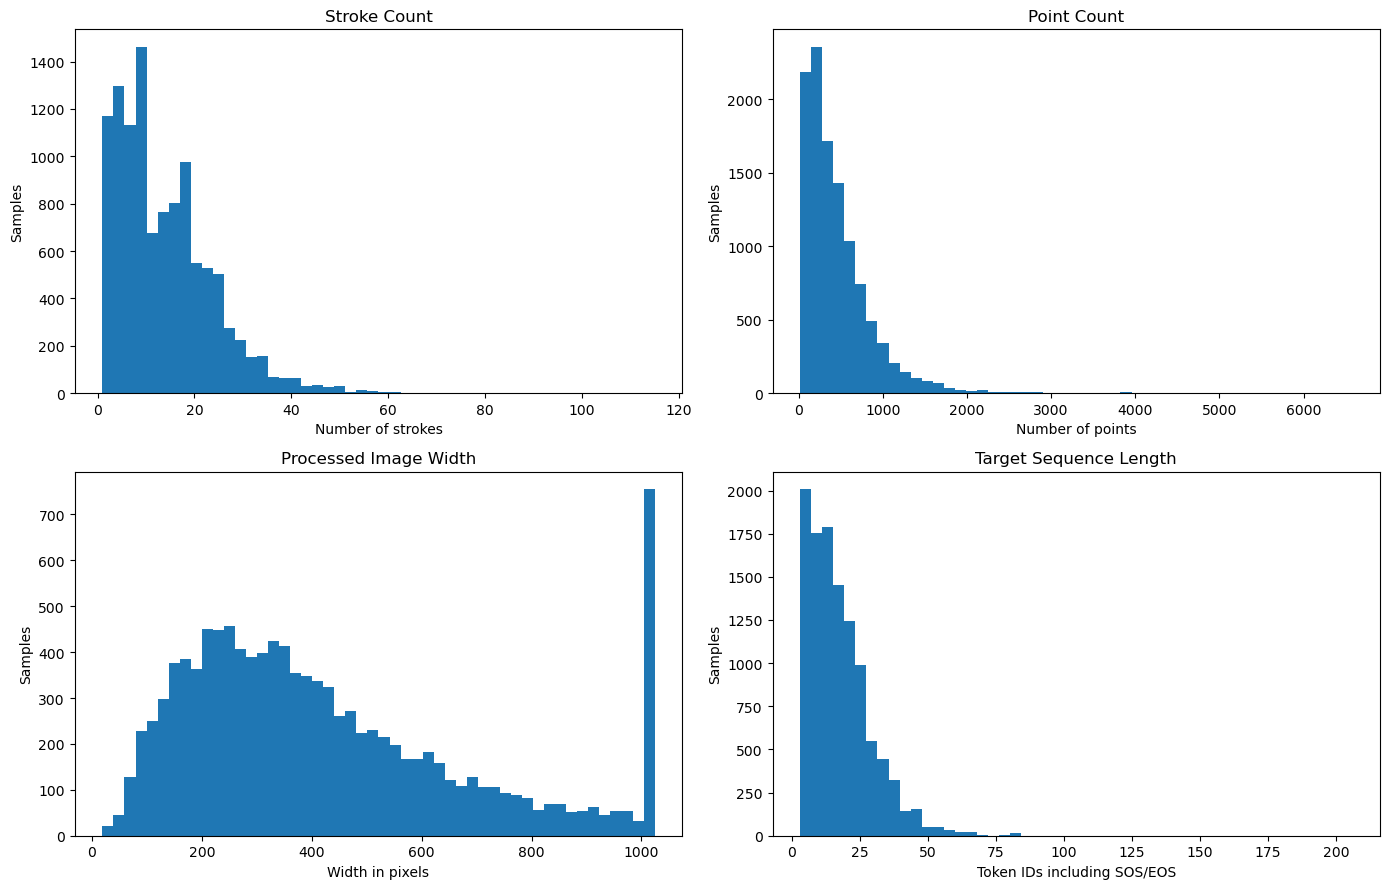

In [22]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 9),
)

axes[0, 0].hist(
    distribution_df["num_strokes"],
    bins=50,
)
axes[0, 0].set_title("Stroke Count")
axes[0, 0].set_xlabel("Number of strokes")
axes[0, 0].set_ylabel("Samples")

axes[0, 1].hist(
    distribution_df["num_points"],
    bins=50,
)
axes[0, 1].set_title("Point Count")
axes[0, 1].set_xlabel("Number of points")
axes[0, 1].set_ylabel("Samples")

axes[1, 0].hist(
    distribution_df["image_width"],
    bins=50,
)
axes[1, 0].set_title("Processed Image Width")
axes[1, 0].set_xlabel("Width in pixels")
axes[1, 0].set_ylabel("Samples")

axes[1, 1].hist(
    distribution_df["sequence_length"],
    bins=50,
)
axes[1, 1].set_title("Target Sequence Length")
axes[1, 1].set_xlabel("Token IDs including SOS/EOS")
axes[1, 1].set_ylabel("Samples")

plt.tight_layout()
plt.show()


## 20. Identify extreme samples

Extreme samples are not automatically invalid. They are collected so they can
be inspected before training.


In [23]:
def top_extremes(df, column, n=15):
    return (
        df.nlargest(n, column)
        [[
            "split",
            "id",
            "num_strokes",
            "num_points",
            "image_width",
            "sequence_length",
            "latex_length",
        ]]
    )


print("Longest target sequences:")
display(top_extremes(distribution_df, "sequence_length"))

print("Most strokes:")
display(top_extremes(distribution_df, "num_strokes"))

print("Most points:")
display(top_extremes(distribution_df, "num_points"))

print("Widest processed images:")
display(top_extremes(distribution_df, "image_width"))


Longest target sequences:


,split,id,num_strokes,num_points,image_width,sequence_length,latex_length
9289,valid,505_em_51,115,1443,487,206,298
8882,train,stat13,99,2829,1024,131,215
6904,train,formulaire009-equation014,55,1353,1017,90,136
8398,train,formulaire032-equation014,64,1481,1024,86,140
5115,train,MfrDB2859,43,3150,378,83,128
5181,train,MfrDB2948,52,2408,379,83,128
5214,train,MfrDB2991,44,1640,617,83,128
5225,train,MfrDB3005,44,1359,412,83,128
5257,train,MfrDB3044,49,2845,389,83,128
5304,train,MfrDB3103,47,1409,446,83,128


Most strokes:


,split,id,num_strokes,num_points,image_width,sequence_length,latex_length
9289,valid,505_em_51,115,1443,487,206,298
8882,train,stat13,99,2829,1024,131,215
3547,train,93_Nina,92,1494,1000,45,98
28,train,105_fujita,75,1369,656,44,50
7251,train,formulaire014-equation037,73,921,991,42,51
21,train,105_Nina,70,1647,637,44,50
7974,train,formulaire025-equation058,70,1142,1024,53,72
9225,valid,501_em_19,69,842,494,60,80
6714,train,formulaire006-equation024,68,1109,1024,82,138
10090,test,UN19_1006_em_82,68,2219,780,70,124


Most points:


,split,id,num_strokes,num_points,image_width,sequence_length,latex_length
8898,valid,18_em_2,39,6581,1024,50,53
8958,valid,26_em_75,24,6276,1003,23,21
8893,valid,18_em_15,16,5983,676,14,14
8892,valid,18_em_14,16,5676,145,27,39
8901,valid,18_em_23,22,5266,270,23,41
8890,valid,18_em_12,21,5153,220,22,26
9191,valid,37_em_2,45,5002,349,53,115
8895,valid,18_em_17,20,4600,449,23,25
8906,valid,18_em_6,15,4570,507,15,13
8891,valid,18_em_13,15,4569,291,17,19


Widest processed images:


,split,id,num_strokes,num_points,image_width,sequence_length,latex_length
65,train,107_edwin,23,547,1024,22,24
283,train,131_Fabricio,39,685,1024,39,48
284,train,131_Frank,38,654,1024,39,48
286,train,131_alfonso,39,1022,1024,39,48
287,train,131_carlos,39,698,1024,39,48
288,train,131_caue,38,964,1024,39,48
289,train,131_david,35,940,1024,39,48
290,train,131_edwin,39,729,1024,39,48
292,train,131_leissi,39,947,1024,39,48
294,train,131_maira,43,791,1024,39,48


## 21. Visual inspection of random samples


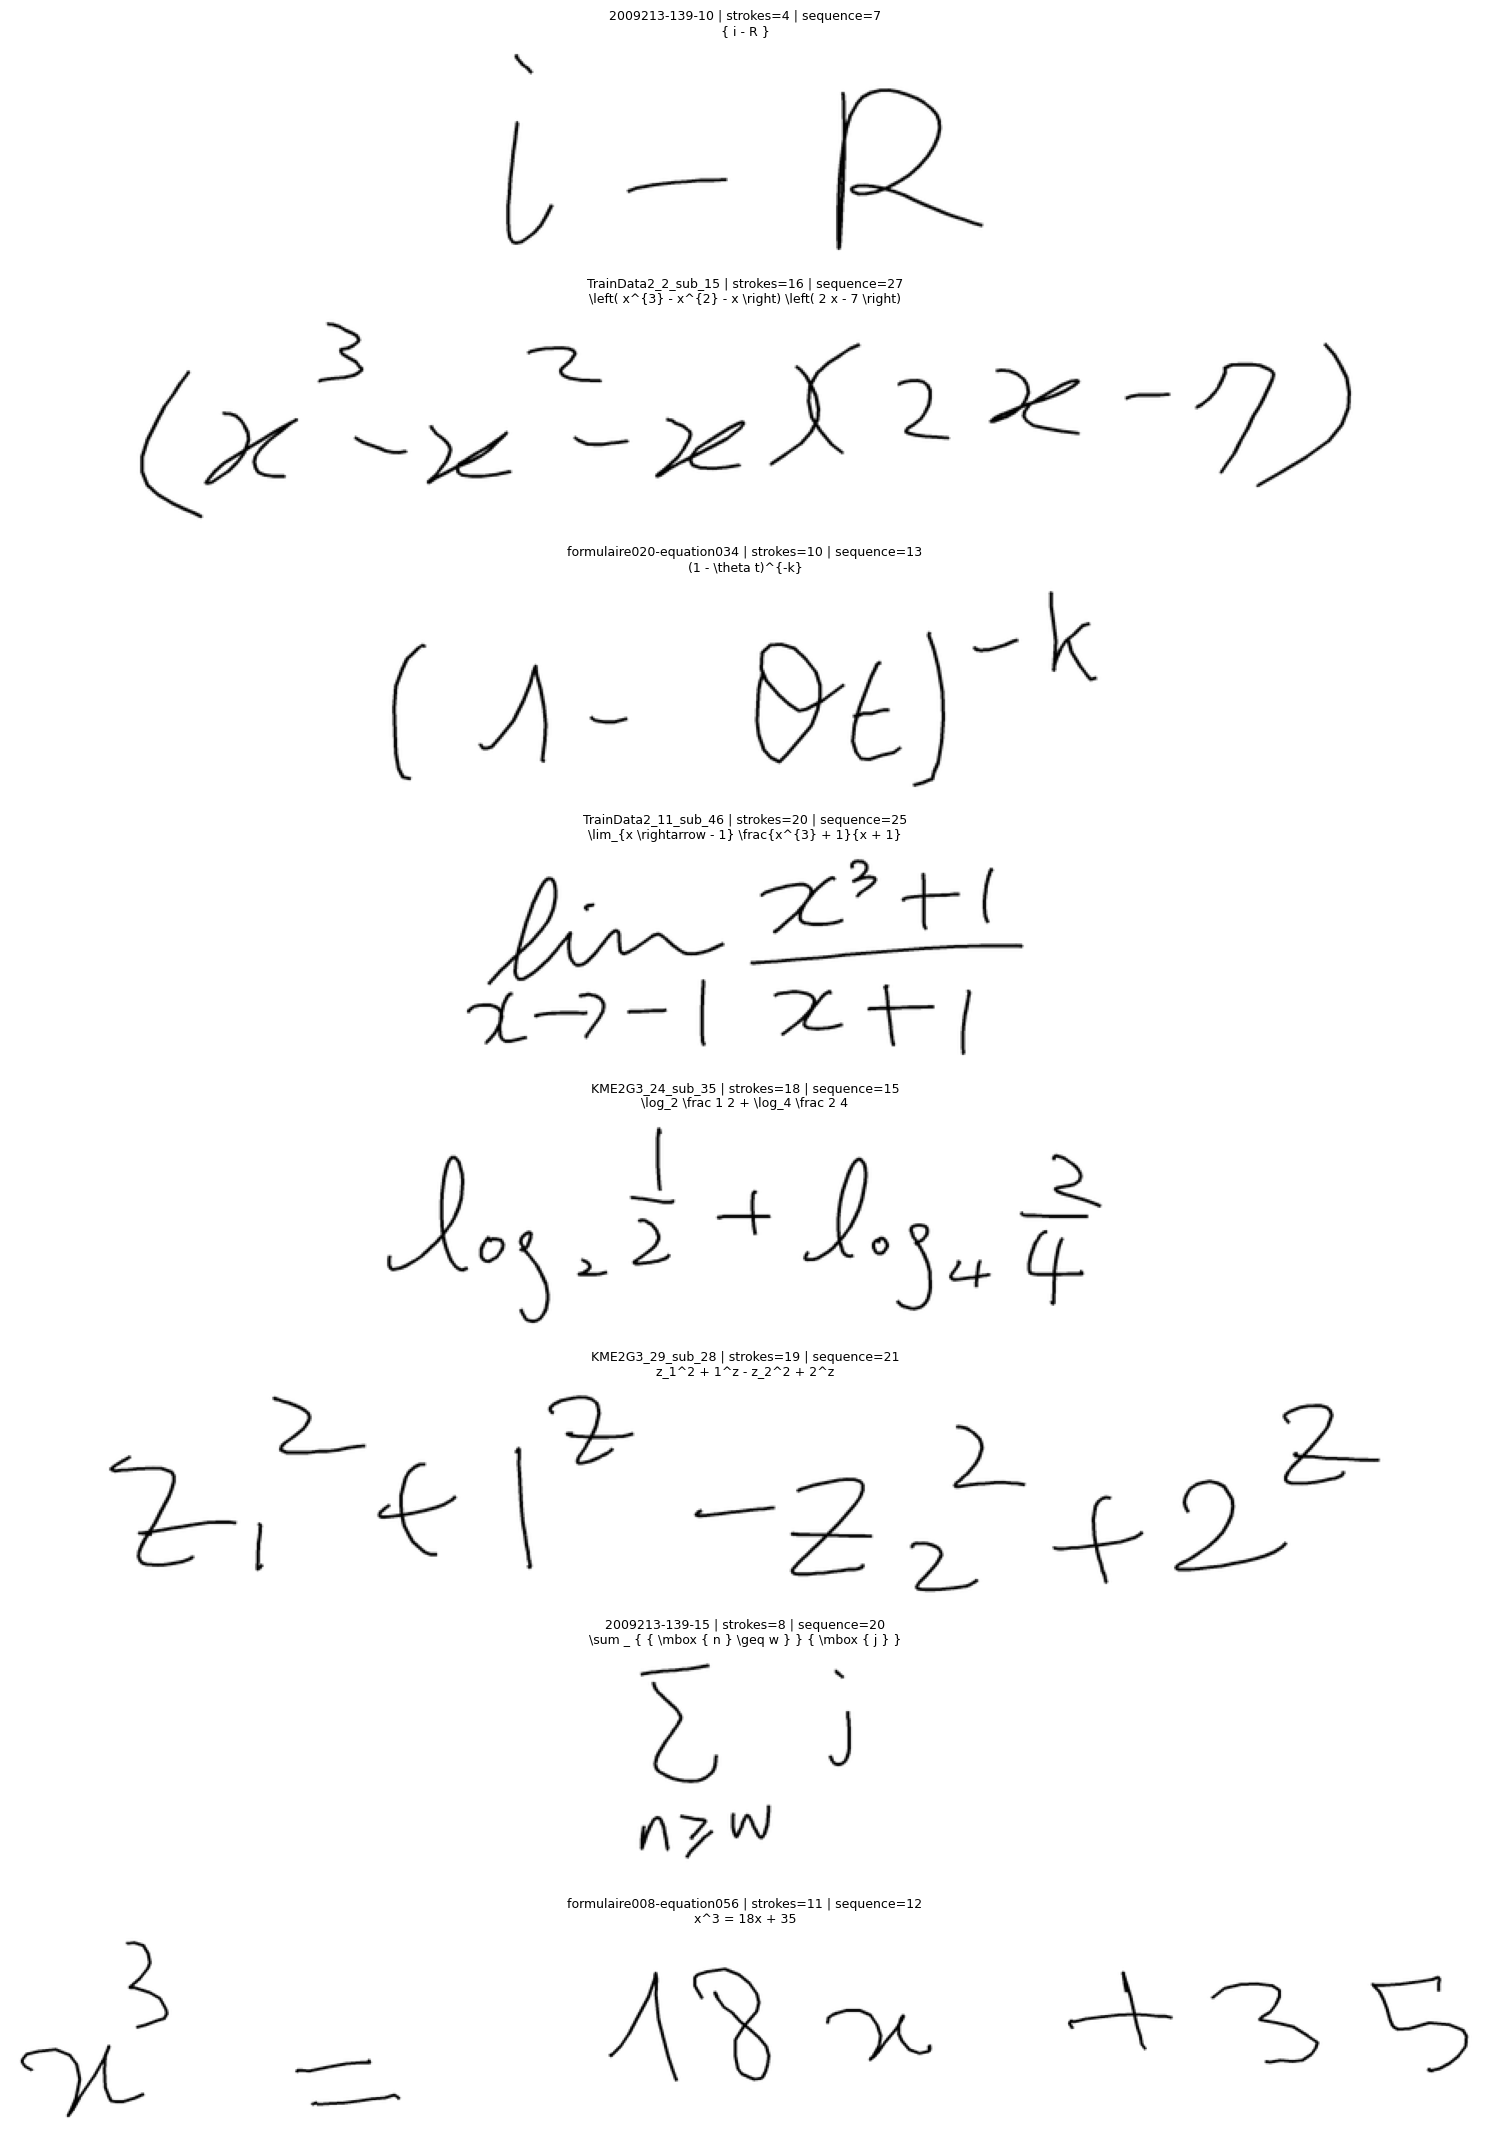

In [24]:
def show_random_samples(records, n=8, seed=42):
    rng = np.random.default_rng(seed)

    if not records:
        print("No records available.")
        return

    n = min(n, len(records))
    indices = rng.choice(
        len(records),
        size=n,
        replace=False,
    )

    fig, axes = plt.subplots(
        n,
        1,
        figsize=(15, max(4, 2.7 * n)),
    )

    if n == 1:
        axes = [axes]

    for ax, index in zip(axes, indices):
        record = records[int(index)]
        image_path = PROCESSED_ROOT / record["image"]

        image = Image.open(image_path).convert("L")

        ax.imshow(image, cmap="gray")
        ax.axis("off")

        ax.set_title(
            f"{record['id']} | "
            f"strokes={record['num_strokes']} | "
            f"sequence={record['sequence_length']}\n"
            f"{record['latex']}",
            fontsize=9,
        )

    plt.tight_layout()
    plt.show()


show_random_samples(train_records, n=8, seed=42)


## 22. Inspect the known failed source file

The exploration notebook reported a malformed XML file. This cell verifies
that the file still exists in the source dataset and is represented in the
failure log rather than silently disappearing.


In [25]:
known_failure_locations = []

for split, directory in [
    ("train", TRAIN_DIR),
    ("valid", VALID_DIR),
    ("test", TEST_DIR),
]:
    path = directory / KNOWN_FAILED_FILE

    if path.exists():
        known_failure_locations.append({
            "split": split,
            "path": str(path),
            "exists": True,
        })

known_failure_locations_df = pd.DataFrame(
    known_failure_locations
)

if known_failure_locations_df.empty:
    print(
        f"{KNOWN_FAILED_FILE} was not found in the current source tree. "
        "This is not necessarily an error if the source dataset was changed."
    )
else:
    display(known_failure_locations_df)

print()
print("Failure log matches:")
display(pd.DataFrame(known_failure_matches))


,split,path,exists
0,train,/data1/students/abhista/HMER/data/crohme2019/t...,True



Failure log matches:


,split,file,source_path,error_type,error
0,train,MfrDB0104.inkml,/data1/students/abhista/HMER/data/crohme2019/t...,ParseError,"not well-formed (invalid token): line 15, colu..."


## 23. Reconcile preprocessing statistics

Compare the current processed dataset with the statistics saved by
`02_crohme_preprocessing.ipynb`.


In [26]:
current_stats = {
    "train_samples": len(train_records),
    "valid_samples": len(valid_records),
    "test_samples": len(test_records),
    "total_samples": sum(
        len(records)
        for records in records_by_split.values()
    ),
    "failed_files": len(failed_files),
    "vocabulary_size": len(token_to_id),
}

print("Current:")
for key, value in current_stats.items():
    print(f"  {key:20s}: {value}")

print()
print("Saved preprocessing statistics:")
for split in ["train", "valid", "test"]:
    print(
        f"  {split:5s}:",
        saved_stats.get(split, {}).get("samples"),
    )
print("  failed_files:      ", saved_stats.get("total_failures"))
print("  vocabulary_size:   ", saved_stats.get("vocabulary_size"))


Current:
  train_samples       : 8886
  valid_samples       : 972
  test_samples        : 1199
  total_samples       : 11057
  failed_files        : 29
  vocabulary_size     : 121

Saved preprocessing statistics:
  train: 8886
  valid: 972
  test : 1199
  failed_files:       29
  vocabulary_size:    121


## 24. Build the final validation report

Errors indicate conditions that should be fixed before training.

Warnings are diagnostic findings that do not necessarily make the dataset
invalid, such as repeated LaTeX targets or low-ink samples.


In [27]:
hard_errors = []

hard_errors.extend(
    [
        f"Missing required path: {item['item']}"
        for item in structure_errors
    ]
)

hard_errors.extend(
    count_df.loc[
        ~count_df["count_match"],
        "split"
    ].map(
        lambda split: f"{split}: processed count does not match "
                      "source count minus failures"
    ).tolist()
)

hard_errors.extend(failure_errors)
hard_errors.extend(vocab_errors)
hard_errors.extend(schema_errors)
hard_errors.extend(token_errors)
hard_errors.extend(image_errors)
hard_errors.extend(dimension_errors)
hard_errors.extend(target_format_errors)

if cross_split_id_duplicates:
    hard_errors.append(
        f"{len(cross_split_id_duplicates)} sample IDs occur across splits."
    )

if cross_split_file_duplicates:
    hard_errors.append(
        f"{len(cross_split_file_duplicates)} filenames occur across splits."
    )

if cross_split_image_duplicates:
    hard_errors.append(
        f"{len(cross_split_image_duplicates)} identical rendered images "
        "occur across multiple splits."
    )

warnings = []

if len(empty_image_df):
    warnings.append(
        f"{len(empty_image_df)} images have effectively no visible ink."
    )

if len(low_ink_image_df):
    warnings.append(
        f"{len(low_ink_image_df)} images have very low ink coverage."
    )

if cross_split_latex:
    warnings.append(
        f"{len(cross_split_latex)} LaTeX targets occur across multiple splits. "
        "This can be legitimate and is not treated as image leakage."
    )

unknown_validation_test = unknown_token_df[
    unknown_token_df["split"].isin(["valid", "test"])
    & (unknown_token_df["unknown_tokens"] > 0)
]

if not unknown_validation_test.empty:
    warnings.append(
        "Validation/test contain tokens unseen in training and therefore "
        "mapped to <UNK>."
    )

report = {
    "status": "PASS" if not hard_errors else "FAIL",
    "hard_error_count": len(hard_errors),
    "warning_count": len(warnings),
    "hard_errors": hard_errors,
    "warnings": warnings,
    "counts": current_stats,
    "known_failed_file": KNOWN_FAILED_FILE,
    "cross_split_id_duplicates": len(cross_split_id_duplicates),
    "cross_split_file_duplicates": len(cross_split_file_duplicates),
    "cross_split_image_duplicates": len(cross_split_image_duplicates),
    "cross_split_latex_targets": len(cross_split_latex),
    "empty_images": len(empty_image_df),
    "low_ink_images": len(low_ink_image_df),
}

report_path = METADATA_DIR / "dataset_validation_report.json"

with report_path.open("w", encoding="utf-8") as handle:
    json.dump(
        report,
        handle,
        indent=2,
        ensure_ascii=False,
    )

print("=" * 70)
print("DATASET VALIDATION REPORT")
print("=" * 70)
print("STATUS:", report["status"])
print("Hard errors:", report["hard_error_count"])
print("Warnings:   ", report["warning_count"])
print()

if hard_errors:
    print("HARD ERRORS:")
    for error in hard_errors[:100]:
        print(" -", error)
    print()

if warnings:
    print("WARNINGS:")
    for warning in warnings:
        print(" -", warning)
    print()

print("Report saved to:")
print(report_path)


DATASET VALIDATION REPORT
STATUS: FAIL
Hard errors: 1
Warnings:    2

HARD ERRORS:
 - train/200923-1253-279: unreadable image: cannot identify image file '/data1/students/abhista/HMER/data/processed/crohme2019/images/train/200923-1253-279.png'

WARNINGS:
 - 16 LaTeX targets occur across multiple splits. This can be legitimate and is not treated as image leakage.
 - Validation/test contain tokens unseen in training and therefore mapped to <UNK>.

Report saved to:
/data1/students/abhista/HMER/data/processed/crohme2019/metadata/dataset_validation_report.json


## 25. Final decision

The processed dataset is ready for the next stage only when there are no hard
validation errors.

Warnings should be reviewed, but they do not automatically block model
development.


In [28]:
if hard_errors:
    print("DATASET STATUS: NOT READY FOR MODEL TRAINING")
    print()
    print("Fix the hard validation errors above and rerun this notebook.")
else:
    print("DATASET STATUS: READY FOR THE MODEL/DATASET STAGE")
    print()
    print(
        "No hard validation errors were detected. "
        "The next step is to implement the PyTorch Dataset/DataLoader "
        "and then establish the first recognition baseline."
    )


DATASET STATUS: NOT READY FOR MODEL TRAINING

Fix the hard validation errors above and rerun this notebook.
